---
## A — Why Not Just Use Linear Regression for Classification?

Suppose you want to predict: **spam (1) or not spam (0)**.

If you use Linear Regression, it predicts **any real number** — like 1.7 or -0.3. That doesn't map to a probability.

Also, it's sensitive to outliers in the class labels: one extreme example can tilt the decision boundary completely.

**We need a model that:**
1. Outputs a number between 0 and 1 (a probability)
2. Applies a clean threshold to make a binary decision

That model is **Logistic Regression**.

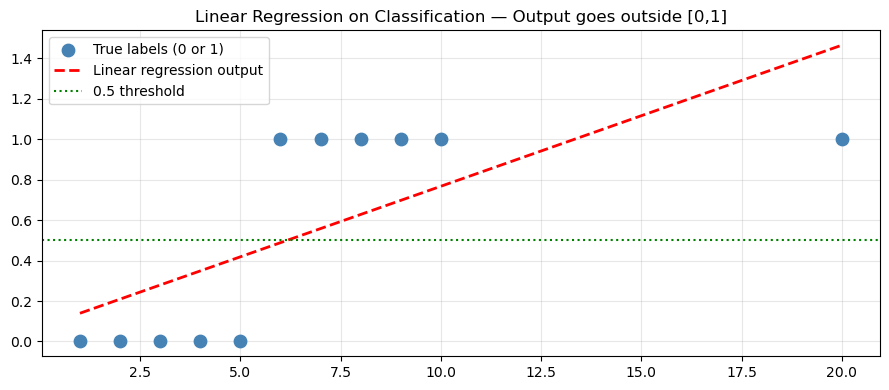

Linear regression predicts >1.0 for the outlier (x=20) — nonsensical probability.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Show why linear regression fails on classification
X_demo = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20], dtype=float)
y_demo = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1,  1], dtype=float)

from sklearn.linear_model import LinearRegression as LR
lin = LR().fit(X_demo.reshape(-1,1), y_demo)
y_lin = lin.predict(X_demo.reshape(-1,1))

plt.figure(figsize=(9, 4))
plt.scatter(X_demo, y_demo, s=80, color='steelblue', zorder=5, label='True labels (0 or 1)')
plt.plot(X_demo, y_lin, 'r--', linewidth=2, label='Linear regression output')
plt.axhline(y=0.5, color='green', linestyle=':', linewidth=1.5, label='0.5 threshold')
plt.title("Linear Regression on Classification — Output goes outside [0,1]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Linear regression predicts >1.0 for the outlier (x=20) — nonsensical probability.")

---
## B — The Sigmoid Function: Squashing Output to [0, 1]

The trick: wrap the linear output inside the **sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where $z = \mathbf{w}^T \mathbf{x} + b$ — same as linear regression.

**Properties of sigmoid:**
- Output is always between 0 and 1
- $\sigma(0) = 0.5$ — equal probability of both classes
- Large positive $z$ → output → 1
- Large negative $z$ → output → 0

So the full model is:

$$\hat{p} = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(w_1 x_1 + \ldots + b)}}$$

And we predict class 1 if $\hat{p} \geq 0.5$, else class 0.

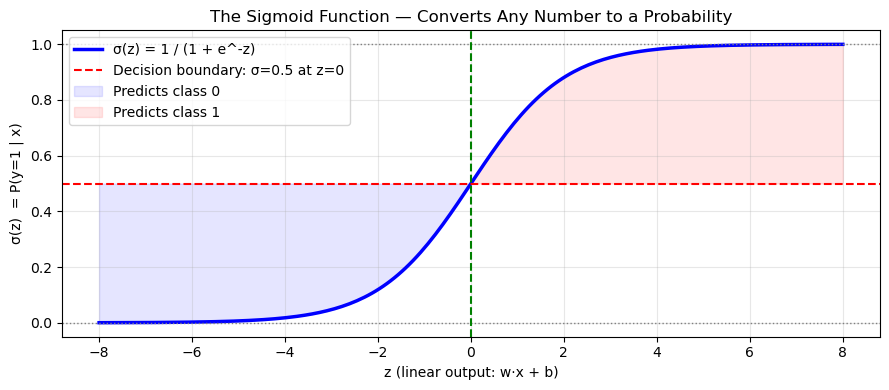

σ(-10) = 0.000045  ← almost certainly class 0
σ(  0) = 0.500000  ← 50/50
σ( 10) = 0.999955  ← almost certainly class 1


In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)
sig = sigmoid(z)

plt.figure(figsize=(9, 4))
plt.plot(z, sig, 'b-', linewidth=2.5, label='σ(z) = 1 / (1 + e^-z)')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Decision boundary: σ=0.5 at z=0')
plt.axhline(y=0,   color='gray', linestyle=':', linewidth=1)
plt.axhline(y=1,   color='gray', linestyle=':', linewidth=1)
plt.axvline(x=0,   color='green', linestyle='--', linewidth=1.5)
plt.fill_between(z, sig, 0.5, where=(z < 0), alpha=0.1, color='blue', label='Predicts class 0')
plt.fill_between(z, sig, 0.5, where=(z > 0), alpha=0.1, color='red', label='Predicts class 1')
plt.xlabel("z (linear output: w·x + b)")
plt.ylabel("σ(z)  = P(y=1 | x)")
plt.title("The Sigmoid Function — Converts Any Number to a Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"σ(-10) = {sigmoid(-10):.6f}  ← almost certainly class 0")
print(f"σ(  0) = {sigmoid(0):.6f}  ← 50/50")
print(f"σ( 10) = {sigmoid(10):.6f}  ← almost certainly class 1")

---
## C — Probability Interpretation + Decision Boundary

The output $\hat{p}$ is the **probability that the sample belongs to class 1**:

$$\hat{p} = P(y=1 \mid \mathbf{x}; \mathbf{w}, b)$$

**Decision boundary** is where $\hat{p} = 0.5$, i.e. where $z = 0$:

$$\mathbf{w}^T \mathbf{x} + b = 0$$

This is a **hyperplane** in feature space (a line in 2D).

> Note: Logistic Regression is a **linear classifier** — the decision boundary is always a straight line (or hyperplane). To get non-linear boundaries, you'd need polynomial features or a different model (e.g. SVM, decision tree, neural network).

---
## D — Binary Cross-Entropy Loss (Why Not MSE?)

If we use MSE with sigmoid, the loss surface becomes **non-convex** — gradient descent can get stuck.

Instead, we use **Binary Cross-Entropy (Log Loss)**:

$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

**Intuition:**
- When $y=1$: loss = $-\log(\hat{p})$ → penalizes heavily when predicted prob is near 0
- When $y=0$: loss = $-\log(1-\hat{p})$ → penalizes heavily when predicted prob is near 1

$$\text{Correct + confident} \rightarrow \text{low loss} \qquad \text{Wrong + confident} \rightarrow \text{high loss}$$

This also has a nice property: the loss surface is **convex** — gradient descent always finds the global minimum.

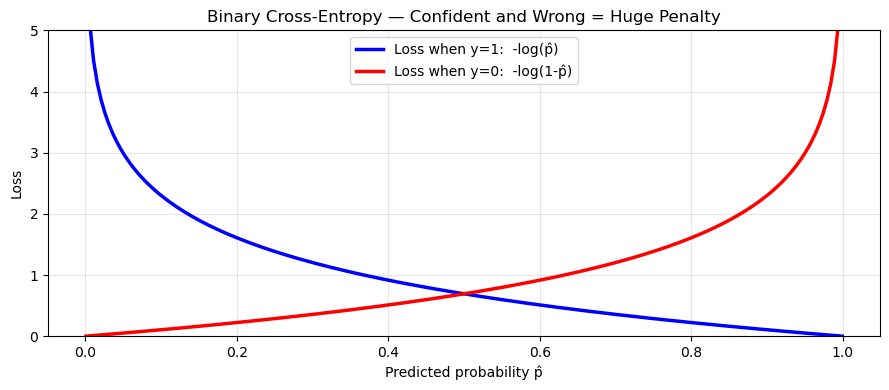

In [3]:
def binary_cross_entropy(y_true, y_pred_prob, eps=1e-15):
    """Clip to avoid log(0)."""
    p = np.clip(y_pred_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

# Show the loss landscape
probs = np.linspace(0.001, 0.999, 200)
loss_y1 = -np.log(probs)             # loss when true label = 1
loss_y0 = -np.log(1 - probs)         # loss when true label = 0

plt.figure(figsize=(9, 4))
plt.plot(probs, loss_y1, 'b-', linewidth=2.5, label='Loss when y=1:  -log(p̂)')
plt.plot(probs, loss_y0, 'r-', linewidth=2.5, label='Loss when y=0:  -log(1-p̂)')
plt.xlabel("Predicted probability p̂")
plt.ylabel("Loss")
plt.title("Binary Cross-Entropy — Confident and Wrong = Huge Penalty")
plt.legend()
plt.ylim(0, 5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## E — Gradient Descent for Logistic Regression

Here's the beautiful part: despite the different loss function, the gradients look almost identical to Linear Regression!

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{n} \mathbf{X}^T (\hat{\mathbf{p}} - \mathbf{y})$$

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{n} \sum (\hat{p}_i - y_i)$$

**Update rules:**
$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \cdot \frac{\partial \mathcal{L}}{\partial \mathbf{w}}$$
$$b \leftarrow b - \alpha \cdot \frac{\partial \mathcal{L}}{\partial b}$$

The only difference from Linear Regression: predictions use sigmoid instead of a plain dot product.

---
## F — From Scratch: Full Logistic Regression

In [ ]:
class LogisticRegressionScratch:
    """Binary Logistic Regression from scratch using Gradient Descent."""

    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.w = None
        self.b = 0.0
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))   # clip for numerical stability

    def predict_proba(self, X):
        return self._sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def fit(self, X, y):
        n, n_feat = X.shape
        self.w = np.zeros(n_feat)

        for i in range(self.n_iter):
            p_hat = self.predict_proba(X)       # sigmoid output
            error = p_hat - y                    # residual

            dw = (1 / n) * X.T @ error           # gradient w.r.t weights
            db = (1 / n) * np.sum(error)         # gradient w.r.t bias

            self.w -= self.lr * dw
            self.b -= self.lr * db

            if i % 100 == 0:
                loss = binary_cross_entropy(y, p_hat)
                self.loss_history.append(loss)

        return self

print("LogisticRegressionScratch class defined — ready to train!")

In [ ]:
# Generate a binary classification dataset
X_data, y_data = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_informative=2, random_state=42, n_clusters_per_class=1
)

X_tr, X_te, y_tr, y_te = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Standardize
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s  = scaler.transform(X_te)

# Train from scratch
log_scratch = LogisticRegressionScratch(learning_rate=0.5, n_iterations=1000)
log_scratch.fit(X_tr_s, y_tr)

acc = accuracy_score(y_te, log_scratch.predict(X_te_s))
print(f"Scratch model accuracy: {acc:.4f}")

# Loss curve
plt.figure(figsize=(7, 4))
plt.plot(range(0, 1000, 100), log_scratch.loss_history, 'b-o', linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss — Logistic Regression From Scratch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def plot_decision_boundary(model, X, y, title, ax, use_proba=True):
    """Plot the decision boundary of a binary classifier."""
    xx = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300)
    yy = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
    XX, YY = np.meshgrid(xx, yy)
    grid = np.c_[XX.ravel(), YY.ravel()]

    if use_proba:
        Z = model.predict_proba(grid)[:, 1].reshape(XX.shape)
    else:
        Z = model.predict_proba(grid).reshape(XX.shape)

    ax.contourf(XX, YY, Z, levels=50, cmap='RdBu_r', alpha=0.6)
    ax.contour(XX, YY, Z, levels=[0.5], colors='black', linewidths=2)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu_r',
                         edgecolors='k', s=30, linewidths=0.5)
    ax.set_title(title)
    ax.grid(True, alpha=0.2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scratch model decision boundary
plot_decision_boundary(log_scratch, X_tr_s, y_tr,
                       f"Scratch Model (acc={accuracy_score(y_te, log_scratch.predict(X_te_s)):.3f})",
                       axes[0], use_proba=False)

# Sklearn model
log_sk = LogisticRegression(random_state=42)
log_sk.fit(X_tr_s, y_tr)
plot_decision_boundary(log_sk, X_tr_s, y_tr,
                       f"Sklearn Model (acc={accuracy_score(y_te, log_sk.predict(X_te_s)):.3f})",
                       axes[1])

plt.suptitle("Decision Boundaries — Black line = 50% probability boundary", y=1.01)
plt.tight_layout()
plt.show()

---
## G — Sklearn: LogisticRegression

One line to train. But sklearn adds regularization by default (`C=1.0` is the inverse of `alpha`).

| Sklearn param | Meaning |
|---------------|---------|
| `C` | Inverse of regularization strength. Larger C = less regularization (default=1.0) |
| `penalty` | `'l2'` (Ridge, default), `'l1'` (Lasso), `'elasticnet'` |
| `solver` | Algorithm: `'lbfgs'` (default, good for most), `'saga'` (needed for L1) |
| `max_iter` | Max gradient descent steps (increase if convergence warning) |

In [ ]:
from sklearn.linear_model import LogisticRegression

log_sk = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
log_sk.fit(X_tr_s, y_tr)

y_pred  = log_sk.predict(X_te_s)
y_proba = log_sk.predict_proba(X_te_s)[:, 1]

print("Sklearn LogisticRegression trained.")
print(f"Learned weights: {log_sk.coef_[0].round(4)}")
print(f"Learned bias:    {log_sk.intercept_[0]:.4f}")
print()
print(f"Test accuracy: {accuracy_score(y_te, y_pred):.4f}")

---
## H — Evaluation: Beyond Accuracy

**Accuracy alone is misleading** — especially with imbalanced classes.

Example: 95% of emails are NOT spam. A model that always predicts "not spam" gets 95% accuracy but catches zero spam.

| Metric | Formula | When it matters |
|--------|---------|-----------------|
| **Accuracy** | (TP+TN) / total | Balanced classes only |
| **Precision** | TP / (TP+FP) | When false positives are costly (e.g. spam filter — don't want to block real emails) |
| **Recall** | TP / (TP+FN) | When false negatives are costly (e.g. cancer detection — don't miss real cases) |
| **F1 Score** | 2 × (P×R)/(P+R) | Balance both precision and recall |
| **ROC-AUC** | Area under ROC curve | Overall model ranking ability across all thresholds |

$$\text{Confusion Matrix:} \quad \begin{pmatrix} TN & FP \\ FN & TP \end{pmatrix}$$

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_te, y_proba)
auc = roc_auc_score(y_te, y_proba)
axes[1].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random classifier (AUC=0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(classification_report(y_te, y_pred, target_names=['Class 0', 'Class 1']))

---
## I — Multi-class Classification

Real problems often have more than 2 classes (e.g. digits 0-9, cat/dog/bird).

**Two main strategies:**

1. **One-vs-Rest (OvR):** Train K binary classifiers — each one answers "is this class K vs everything else?" (default in sklearn)

2. **Softmax (Multinomial LR):** One model directly outputs K probabilities that sum to 1 using the softmax function:
$$P(y=k | \mathbf{x}) = \frac{e^{\mathbf{w}_k^T \mathbf{x}}}{\sum_{j=1}^K e^{\mathbf{w}_j^T \mathbf{x}}}$$

Sklearn automatically handles multi-class with `multi_class='auto'`.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder

iris = load_iris()
X_iris = iris.data[:, :2]   # use first 2 features for visualization
y_iris = iris.target          # 3 classes: setosa, versicolor, virginica

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)
sc_i = StandardScaler()
X_tr_is = sc_i.fit_transform(X_tr_i)
X_te_is  = sc_i.transform(X_te_i)

mc_model = LogisticRegression(multi_class='auto', max_iter=1000, random_state=42)
mc_model.fit(X_tr_is, y_tr_i)

y_pred_i = mc_model.predict(X_te_is)
print(f"Iris 3-class accuracy: {accuracy_score(y_te_i, y_pred_i):.4f}")
print()
print(classification_report(y_te_i, y_pred_i, target_names=iris.target_names))

# Decision boundary for 3 classes
xx = np.linspace(X_tr_is[:,0].min()-0.5, X_tr_is[:,0].max()+0.5, 300)
yy = np.linspace(X_tr_is[:,1].min()-0.5, X_tr_is[:,1].max()+0.5, 300)
XX, YY = np.meshgrid(xx, yy)
Z = mc_model.predict(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)

plt.figure(figsize=(8, 5))
plt.contourf(XX, YY, Z, alpha=0.4, cmap='RdYlBu')
plt.scatter(X_tr_is[:,0], X_tr_is[:,1], c=y_tr_i, cmap='RdYlBu',
            edgecolors='k', s=30, linewidths=0.5, label='Train')
plt.scatter(X_te_is[:,0], X_te_is[:,1], c=y_te_i, cmap='RdYlBu',
            edgecolors='k', s=80, marker='^', linewidths=1.5, label='Test')
plt.title(f"Logistic Regression — 3-Class (Iris)  Acc={accuracy_score(y_te_i, y_pred_i):.3f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🏁 Summary

```
Linear output → Sigmoid → Probability → Threshold → Class label
```

| What you learned | Key takeaway |
|-----------------|-------------|
| Why not Linear Reg | Outputs go outside [0,1] — not valid probabilities |
| Sigmoid | Maps any real number to (0, 1) — clean probability |
| Decision boundary | Where $\hat{p} = 0.5$ — a line (linear classifier) |
| Binary Cross-Entropy | The right loss for classification; convex surface |
| Gradients | Same structure as Linear Regression, just with sigmoid |
| Scratch impl. | < 40 lines of clean NumPy |
| Sklearn | `LogisticRegression` — handles L1/L2, multi-class automatically |
| Evaluation | Accuracy, Precision, Recall, F1, ROC-AUC — pick based on your problem |
| Multi-class | OvR (default) or Softmax (`multinomial`) |

### When to use Logistic Regression?
- Binary or multi-class classification
- You want **interpretable** coefficients (each weight = log-odds contribution)
- You want **calibrated probabilities** (not just class labels)
- The decision boundary is roughly linear

### What's Next?
- **Support Vector Machines (SVM)** — different way to find the optimal boundary
- **Decision Trees / Random Forests** — non-linear classifiers
- **Neural Networks** — logistic regression is literally one neuron, that's all